In [23]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [30]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

def compare_support(X, Y, thr=0.05):
    """
    Compare the binary ‘non-zero’ supports of two fitted tensors.
    Parameters
    ----------
    X, Y : torch.Tensor  (same shape)
        Reconstructions you want to compare.
    thr : float
        Entries ≤ thr are treated as structural zeros.
    Returns
    -------
    dict with TP, FP, FN counts + agreement metrics.
    """
    Sx = X > thr                       # support of your fit
    Sy = Y > thr                       # support of Aaron’s fit

    tp = (Sx &  Sy).sum().item()       # both predict non-zero
    fp = (Sx & ~Sy).sum().item()       # you only
    fn = (~Sx & Sy).sum().item()       # Aaron only
    union = (Sx | Sy).sum().item()

    precision = tp / (tp + fp) if tp + fp else 1.0
    recall    = tp / (tp + fn) if tp + fn else 1.0
    f1        = 2*precision*recall / (precision + recall) if precision+recall else 0.0
    jaccard   = tp / union if union else 1.0

    return dict(tp=tp, fp=fp, fn=fn,
                precision=precision, recall=recall,
                f1=f1, jaccard=jaccard)

# Generate data

In [25]:
use_existing_data = True

rn.seed(0)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = sparse.COO(data)
    print(f'Percentage of cells that are non-zero: {data.data.shape[0] / np.prod(np.array(list(data.shape))) * 100: .3}%')
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = sparse.COO(data)

Percentage of cells that are non-zero:  0.713%


# Fit with BPTF

In [26]:
n_components = 50
max_iter = 500
device = 'cuda'
tol = 1e-6

mask = np.zeros(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 1

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 1
mask = sparse.COO(mask.astype(np.int64))

# BPTF_model_withmask = BPTF(data_shape=data.shape, n_components=n_components)
# BPTF_model_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

BPTF_model_nomask = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model_nomask.fit(data, mask = None, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

 35%|███▌      | 175/500 [14:27<26:51,  4.96s/it]


BPTF(data_shape=(280, 280, 20, 12, 3), n_components=50)

# Fit with own BPTF_torch

In [27]:
from own_implementation import BPTF as BPTF_torch

Change is small enough, early break:  63%|██████▎   | 313/500 [11:37<06:56,  2.23s/it]                           

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2919993448.067297, 8316998.122087567, 8518570.59676721, 9207273.053491391, 10764433.573906016, 13037458.912221117, 15140514.916628957, 16573995.801557202, 17434870.479941465, 17924758.24118296, 18219967.915260203, 18407437.063057467, 18534236.233269904, 18628815.892237846, 18705607.92557917, 18767472.16093571, 18811709.13955977, 18843828.450162444, 18869506.497031968, 18891255.52042148, 18909790.1522974, 18925573.62038146, 18939375.047388986, 18951751.033585742, 18963063.610026304, 18973308.418736234, 18982522.296175413, 18990995.465293165, 18998823.603320185, 19005919.843796603, 19012179.869327117, 19017633.312447716, 19022422.615970492, 19026688.27656376, 19030552.106298983, 19034153.711690072, 19037539.959638387, 19040683.06840609, 19043575.254618634, 19046219.362707943, 19048629.703259192, 19050841.040741175, 19052894.519892048, 19054847.028233778, 19056751.54547842, 19058648.58880571, 

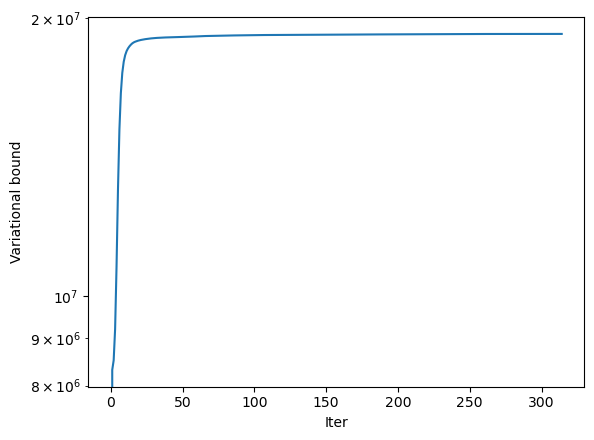

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [28]:
mask = (1 - mask.todense()).astype(np.int64)
mask = torch.tensor(mask, dtype=torch.float64, device=device)

data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch_nomask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch_nomask.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# BPTF_model_torch_withmask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
# BPTF_model_torch_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

## No mask

Frobenius norm relative difference: 0.23860812054727523
Proportion of elements with difference greater than 0.05 = 0.04102297689909297
tensor(0.9773, device='cuda:0') tensor(0.1616, device='cuda:0') tensor(2230.0297, device='cuda:0')


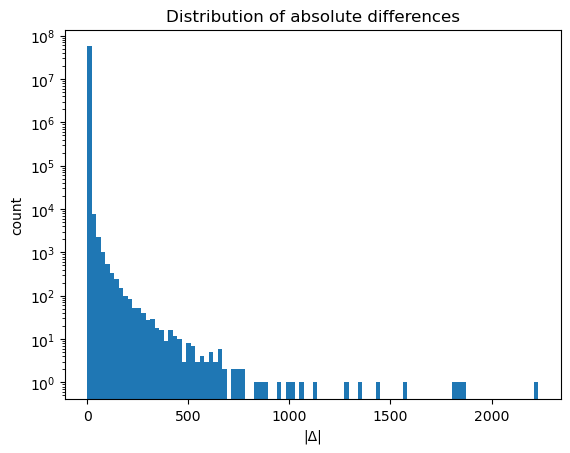

tensor([191266, 185394, 191519, 203495, 205365, 216161, 184690, 188987, 187268,
        196994, 191925, 172601], device='cuda:0')
{'tp': 3001676, 'fp': 499039, 'fn': 504151, 'precision': 0.8574465502047439, 'recall': 0.8561962698102331, 'f1': 0.8568209539027954, 'jaccard': 0.7495072244614427}
(array([203,  47, 203, 209,  47,  47, 203, 203, 203, 203, 203,  47, 121,
       121, 209, 121, 203, 121, 126, 279], dtype=int64), array([121,  47, 121, 209,  47,  47, 121, 121, 121, 121, 121,  47, 121,
       203, 126, 261, 121, 203, 209, 279], dtype=int64), array([18,  3,  3,  3,  3,  3, 18,  3, 18, 10,  3,  3,  3,  3,  3,  3, 18,
        3,  3,  3], dtype=int64), array([ 9,  5,  9,  5,  6, 10,  4, 10, 10,  9, 11,  9,  7,  4, 10,  9, 11,
        7, 10,  3], dtype=int64), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64))


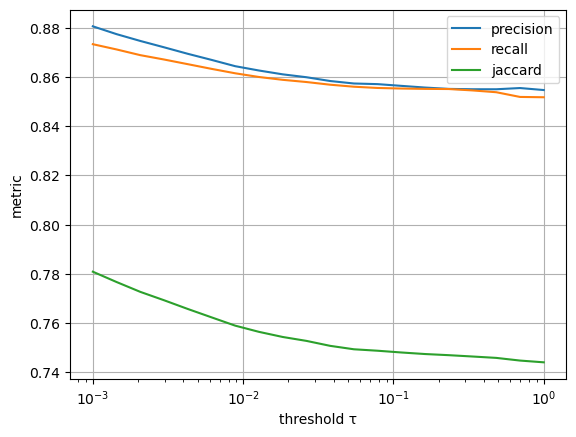

In [37]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')
plt.show()

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month

# Check whether the predictions for nnz locations are the same
nnz_prediction_stats = compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=0.05)
print(nnz_prediction_stats)

diff = (BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))).abs()
idx   = diff.flatten().topk(20).indices
print(np.unravel_index(idx.cpu(), diff.shape))

thrs = np.logspace(-3, 0, 20)          # 0.001 … 1
stats = [compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=t) for t in thrs]

prec = [s['precision'] for s in stats]
rec  = [s['recall']    for s in stats]
jacc = [s['jaccard']   for s in stats]

plt.semilogx(thrs, prec, label='precision')
plt.semilogx(thrs, rec,  label='recall')
plt.semilogx(thrs, jacc, label='jaccard')
plt.xlabel('threshold τ'); plt.ylabel('metric'); plt.legend(); plt.grid(True)
plt.show()

## With mask

Frobenius norm relative difference: 0.009975108869407034
Proportion of elements with difference greater than 0.05 = 0.023552430555555556
tensor(1.5242, device='cuda:0') tensor(0.1695, device='cuda:0') tensor(1204.6264, device='cuda:0')
tensor([ 43168,   9978,  20860, 115746,  51908,  27598, 175263,   2054,  74549,
         98644,  31002,  27540], device='cuda:0')


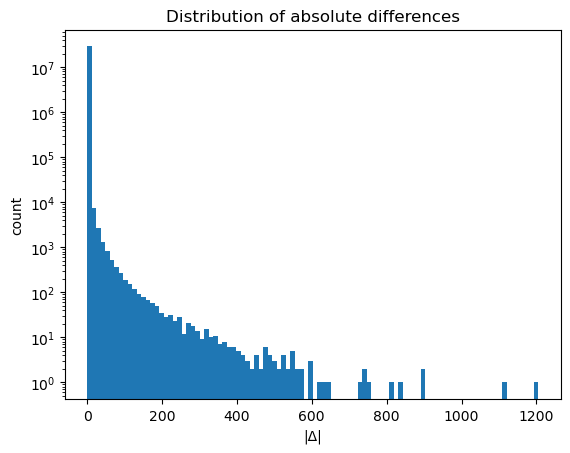

In [ ]:
# BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_withmask.G_DK_M]
# fro_norm_rel_diff = torch.norm(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
# print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

# threshold = 0.05
# diff = torch.abs(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
# prop_exceed = (diff > threshold).sum().item() / diff.numel()
# print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# # 1) How big are the large errors?
# big = diff[diff > 0.05]
# print(big.mean(), big.median(), big.max())

# # 2) Histogram of the absolute differences
# import matplotlib.pyplot as plt
# plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
# plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# # 3) Where do they occur?  Example for mode-4 time slices
# exceed_mask = (diff > 0.05)
# time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
# print(time_exceed)  # counts per month